# Labeling Nuances
This document contains notes on the preprocessing code that is used to assign damage and "uncertain" class to each observational unit.

Logic: 
* Stage 1: Back fill everything before the first valid annotation date as -1
* Stage 2: Forward fill everything after the last valid annotation date with the value observed during the date of  last annotation
* Stage 3: Mark all entries which lie at the in-between zone between two values (0 and 2) as -1
* Stage 4: Forward fill the remainder. 


```python
# # Fills missing dates
damage[list(set(dates) - set(damage.columns))] = np.nan
damage = damage.reindex(sorted(damage.columns), axis=1)
values = damage.drop(columns='geometry').T
first =list(values[:values[0].first_valid_index()].T.columns)
del first[-1]
values.loc[first] = -1
last =list(values[values[0].last_valid_index():].T.columns)
values.loc[last] = values.loc[last].fillna(method='ffill')
values[values.fillna(method='ffill') != values.fillna(method='bfill')] = -1
values = values.fillna(method='ffill')
damage = geopandas.GeoDataFrame(values.T.astype(int), geometry=damage.geometry)
damage = damage[dates + ['geometry']] # Drops dates not in images
del values
```

## Stage 1
### Back fill everything before the first valid annotation date as -1

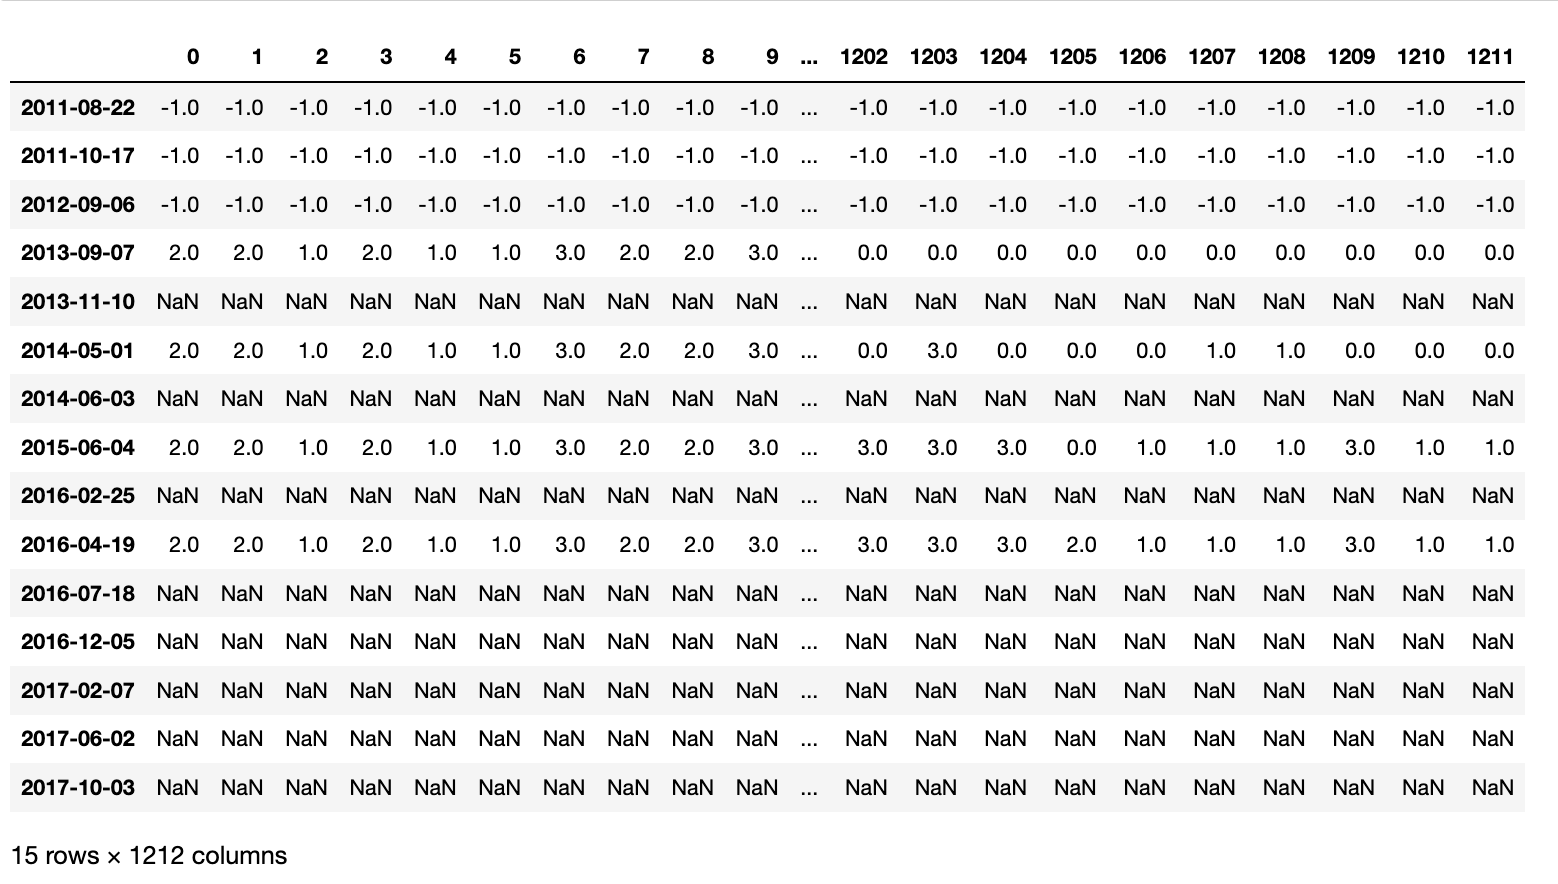



## Stage 2
### Forward fill everything after the last valid annotation date with the value observed during the date of  last annotation

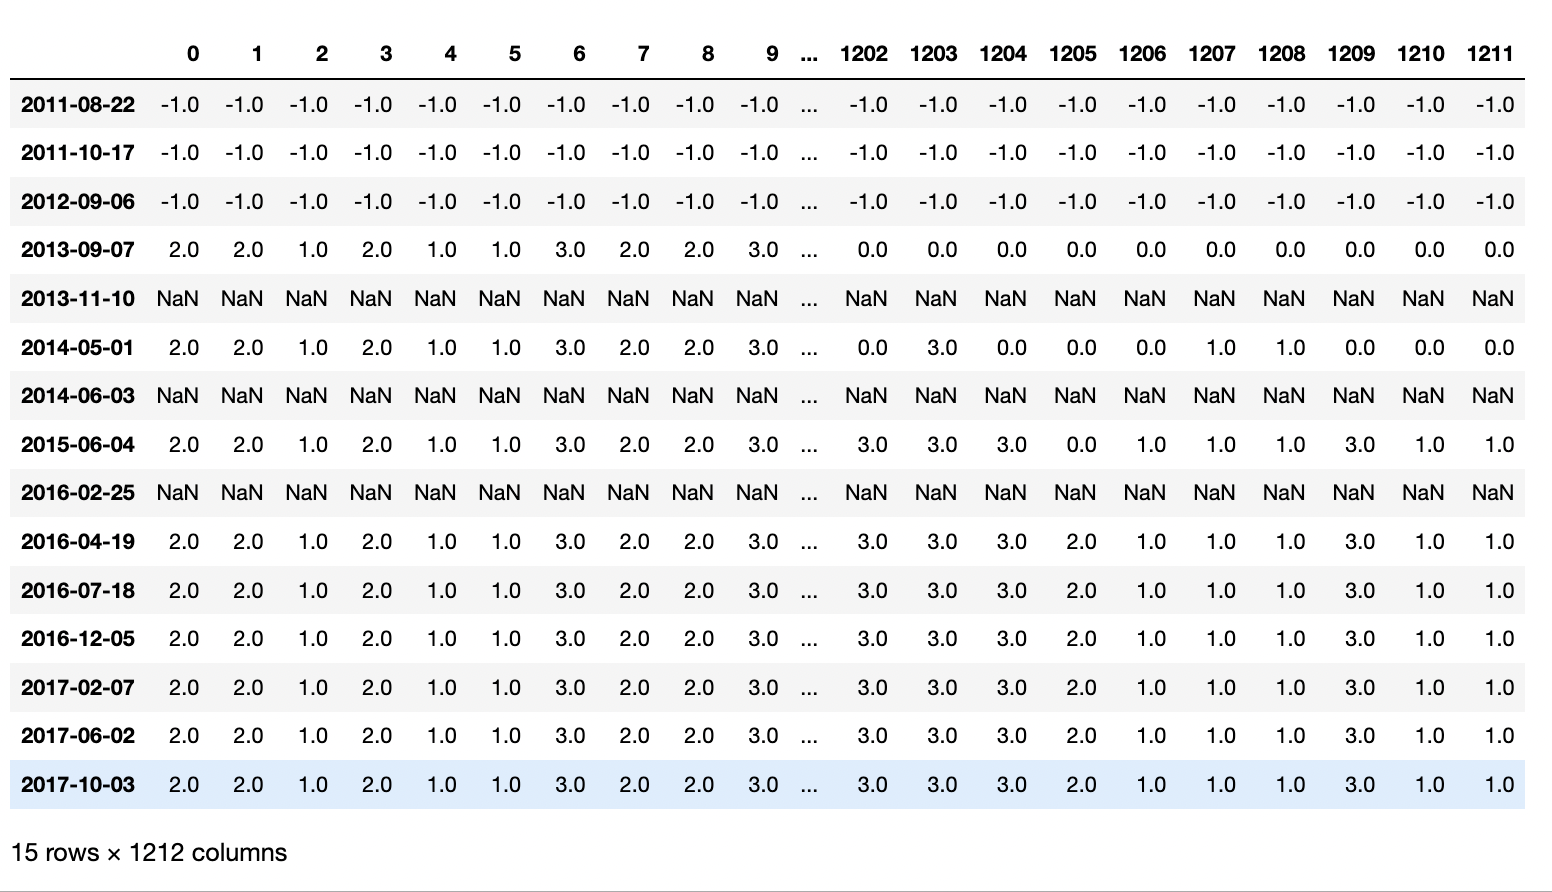

##  Stage 3
### Mark all entries which lie at the in-between zone between two values (0 and 2) as -1

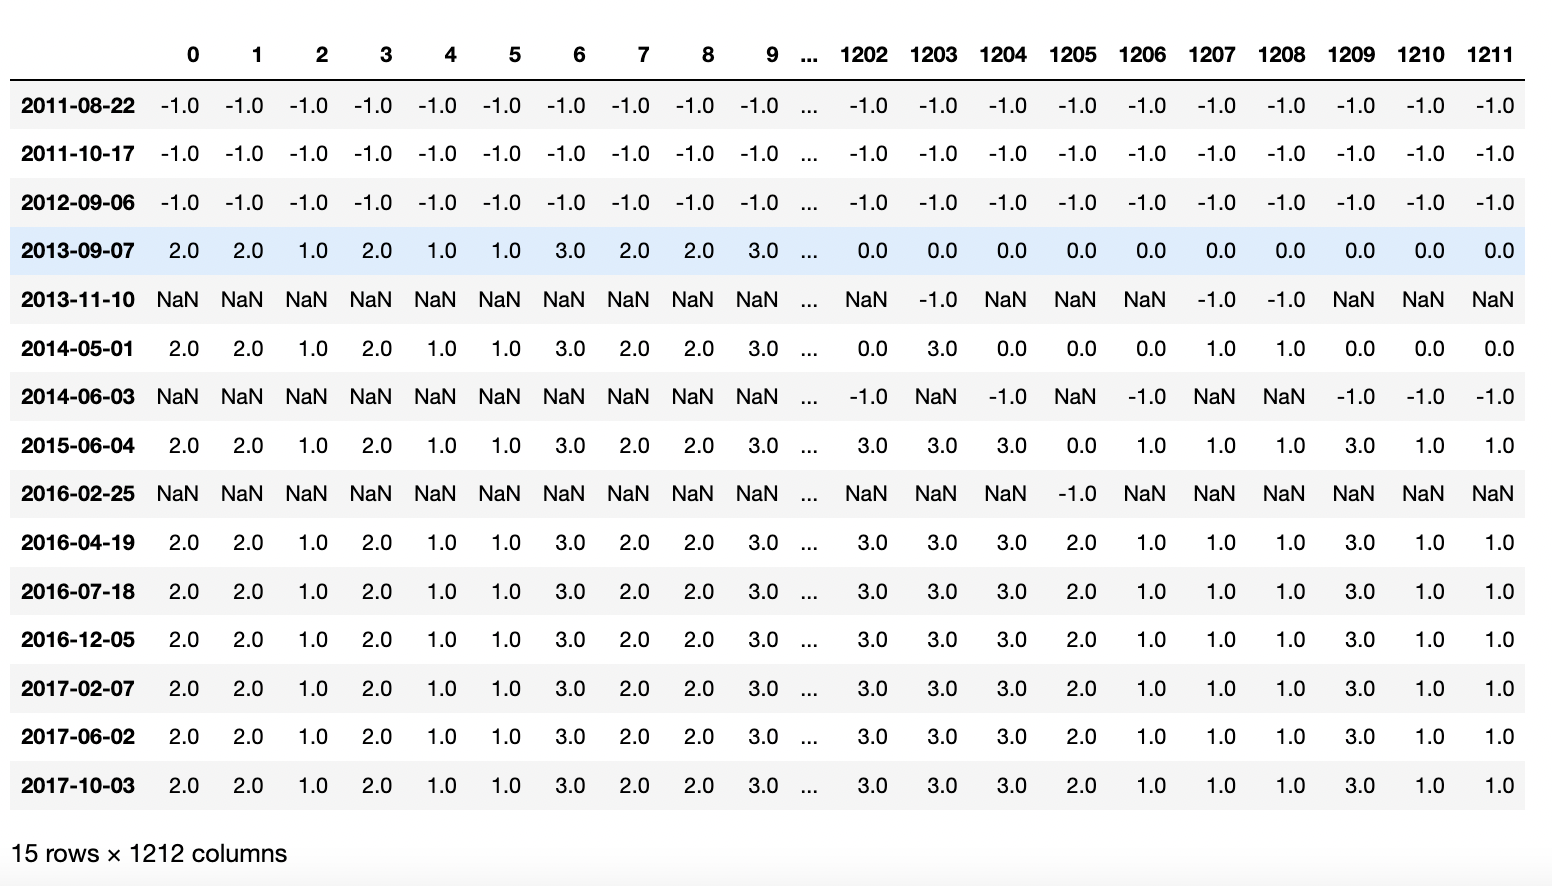

## Stage 4
### Forward fill the remainder. 


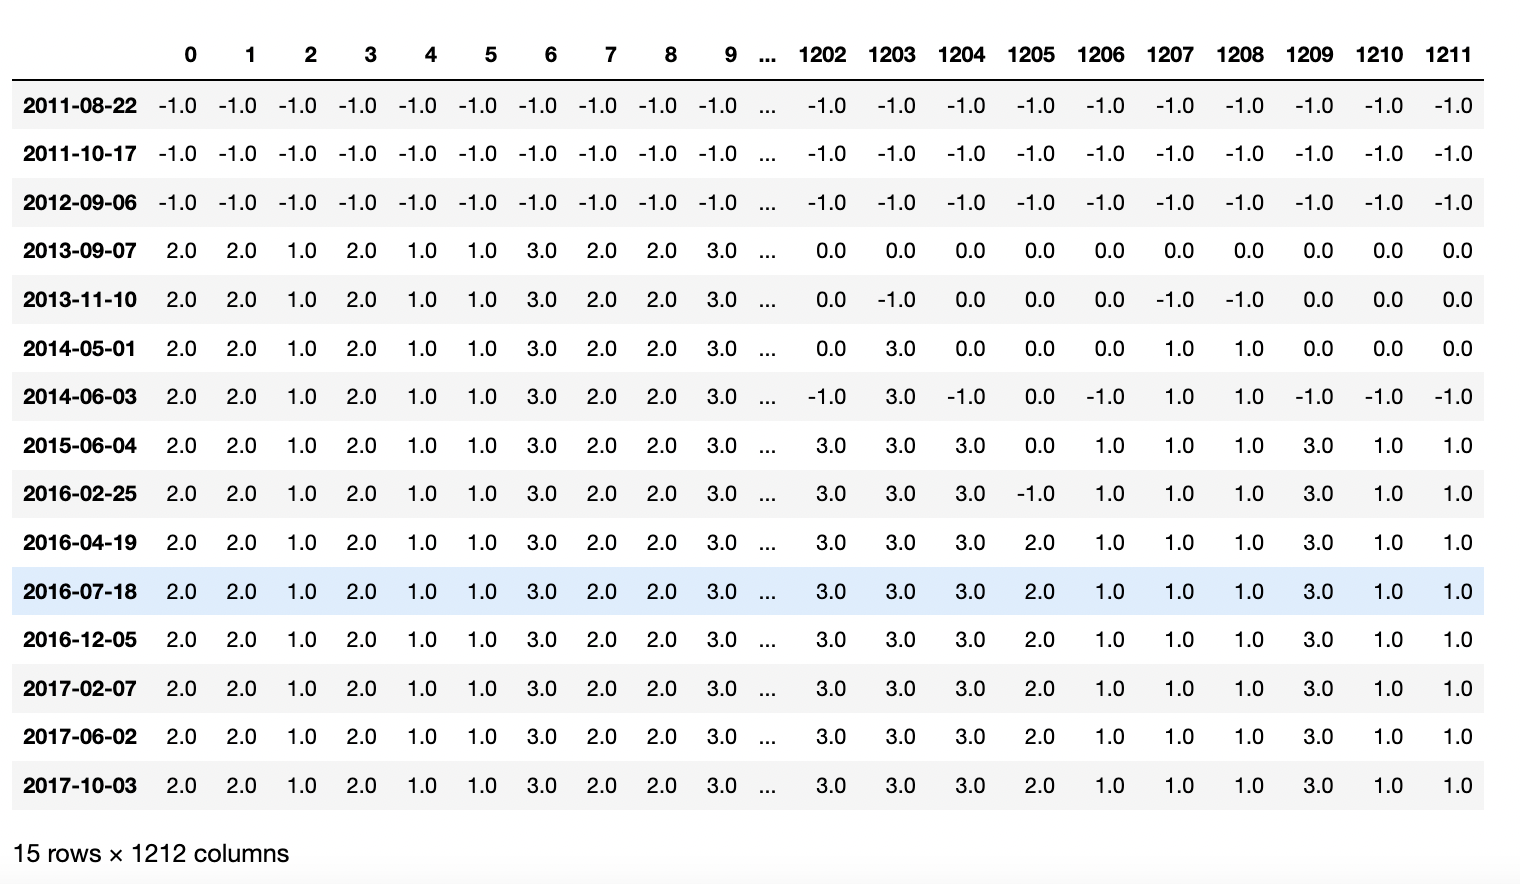